# Stats method

This notebook opens the same cached climate tensor as the ConvLSTM notebook. For each retained feature it:

1. forms a spatial mean for every month
2. averages those monthly values into annual means
3. does linear fit using only years before the inflection year
4. compares each post inflection annual mean with the extrapolated fit

The z-score is `(observed - fitted) / predictive uncertainty`. Predictive uncertainty combines the pre-inflection residual standard deviation with uncertainty in the fitted mean line. Positive z-scores mean the observed annual value lies above the pre-inflection trend; negative values mean it lies below.

`predictive uncertainty = sqrt(sigma^2 + uncertainty on fit^2)`

In [1]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=RuntimeWarning)
pd.set_option("display.max_columns", None)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
CACHE_PATH = Path(
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed"
    r"\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc"
)
INFLECTION_YEAR = 1982
MIN_PRE_YEARS = 3

OUTPUT_DIR = Path(os.environ.get(
    "LINEAR_ZSCORE_OUTPUT_DIR",
    str(CACHE_PATH.parent / f"linear_baseline_zscores_{INFLECTION_YEAR}"),
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Tensor:", CACHE_PATH)
print("Inflection year:", INFLECTION_YEAR)
print("Outputs:", OUTPUT_DIR)

Tensor: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\oras5_era5_monthly_25N_45N_50W_30W_0p5deg.nc
Inflection year: 1982
Outputs: C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\Processed\linear_baseline_zscores_1982


In [31]:
if not CACHE_PATH.exists():
    raise FileNotFoundError(f"Cached tensor not found:\n{CACHE_PATH}")

with xr.open_dataset(CACHE_PATH, engine="h5netcdf") as ds:
    if "climate" in ds.data_vars:
        combined_monthly = ds["climate"].load()
    elif len(ds.data_vars) == 1:
        combined_monthly = ds[next(iter(ds.data_vars))].load()
    else:
        raise ValueError(f"Could not identify tensor variable: {list(ds.data_vars)}")

required_dims = {"time", "feature", "lat", "lon"}
if not required_dims.issubset(combined_monthly.dims):
    raise ValueError(f"Tensor dimensions must include {required_dims}; found {combined_monthly.dims}")

combined_monthly = (
    combined_monthly.sortby("time")
    .transpose("time", "feature", "lat", "lon")
    .where(np.abs(combined_monthly) < 1e10)
    .astype(np.float32)
)
combined_monthly = combined_monthly.assign_coords(
    feature=combined_monthly.feature.values.astype(str)
)

times = pd.DatetimeIndex(pd.to_datetime(combined_monthly.time.values))
candidate_features = combined_monthly.feature.values.astype(str).tolist()
pre_mask = times.year < INFLECTION_YEAR
if not pre_mask.any():
    raise ValueError("No tensor observations occur before INFLECTION_YEAR.")

quality_rows = []
retained_features = []
for name in candidate_features:
    values = combined_monthly.sel(feature=name).values
    finite_fraction = float(np.isfinite(values).mean())
    pre_std = float(np.nanstd(values[pre_mask]))
    keep = finite_fraction > 0 and np.isfinite(pre_std) and pre_std > 1e-8
    quality_rows.append({
        "feature": name, "finite_fraction": finite_fraction,
        "pre_inflection_std": pre_std, "retained": keep,
    })
    if keep:
        retained_features.append(name)

quality = pd.DataFrame(quality_rows)
#display(quality)
if not retained_features:
    raise ValueError("No non-empty, non-constant features remain.")
combined_monthly = combined_monthly.sel(feature=retained_features)
#print("Shape (time, feature, lat, lon):", combined_monthly.shape)
#print("Retained features:", retained_features)
#print("Range:", times.min().strftime("%Y-%m"), "to", times.max().strftime("%Y-%m"))

In [30]:
lat_weights = xr.DataArray(
    np.cos(np.deg2rad(combined_monthly.lat.values)),
    coords={"lat": combined_monthly.lat}, dims=("lat",),
)
monthly_box_mean = combined_monthly.weighted(lat_weights).mean(
    dim=("lat", "lon"), skipna=True
)
annual_box_mean = monthly_box_mean.groupby("time.year").mean("time", skipna=True)
annual_box_mean.name = "annual_box_mean"
annual_df = annual_box_mean.to_pandas()
annual_df.index = annual_df.index.astype(int)
annual_df.index.name = "year"
annual_df.columns.name = "feature"
#display(annual_df.head())
#print(f"Annual means: {annual_df.index.min()}-{annual_df.index.max()}")

In [29]:
def fit_pre_inflection_line(years, values, inflection_year, min_pre_years=3):
    """OLS fit with x=year-inflection_year and analytical uncertainty."""
    years = np.asarray(years, dtype=float)
    values = np.asarray(values, dtype=float)
    valid = np.isfinite(years) & np.isfinite(values) & (years < inflection_year)
    x = years[valid] - float(inflection_year)
    y = values[valid]
    if y.size < max(min_pre_years, 3):
        raise ValueError(f"Need at least {max(min_pre_years, 3)} valid pre-inflection years; found {y.size}.")

    X = np.column_stack([np.ones_like(x), x])
    xtx_inv = np.linalg.inv(X.T @ X)
    beta = xtx_inv @ X.T @ y
    fitted = X @ beta
    residuals = y - fitted
    dof = y.size - X.shape[1]
    residual_variance = float((residuals @ residuals) / dof)
    covariance = residual_variance * xtx_inv

    return {
        "intercept_at_inflection": float(beta[0]),
        "slope_per_year": float(beta[1]),
        "intercept_se": float(np.sqrt(covariance[0, 0])),
        "slope_se": float(np.sqrt(covariance[1, 1])),
        "residual_std": float(np.sqrt(residual_variance)),
        "r_squared": float(1 - (residuals @ residuals) / np.sum((y - y.mean()) ** 2))
            if np.sum((y - y.mean()) ** 2) > 0 else np.nan,
        "n_pre_years": int(y.size),
        "degrees_of_freedom": int(dof),
        "covariance": covariance,
    }

parameter_rows = []
post_rows = []
fit_details = {}
years = annual_df.index.to_numpy(dtype=float)

for feature in annual_df.columns:
    values = annual_df[feature].to_numpy(dtype=float)
    fit = fit_pre_inflection_line(years, values, INFLECTION_YEAR, MIN_PRE_YEARS)
    fit_details[feature] = fit
    parameter_rows.append({k: v for k, v in fit.items() if k != "covariance"} | {"feature": feature})

    for year, observed in zip(years, values):
        if year < INFLECTION_YEAR or not np.isfinite(observed):
            continue
        x0 = np.array([1.0, year - INFLECTION_YEAR])
        expected = fit["intercept_at_inflection"] + fit["slope_per_year"] * x0[1]
        fitted_mean_variance = float(x0 @ fit["covariance"] @ x0)
        predictive_se = np.sqrt(fit["residual_std"] ** 2 + fitted_mean_variance)
        post_rows.append({
            "year": int(year), "feature": feature, "observed": float(observed),
            "expected_from_pre_trend": float(expected),
            "difference": float(observed - expected),
            "fitted_mean_se": float(np.sqrt(fitted_mean_variance)),
            "predictive_se": float(predictive_se),
            "z_score": float((observed - expected) / predictive_se),
        })

parameters = pd.DataFrame(parameter_rows).set_index("feature")
parameters = parameters[[
    "slope_per_year", "slope_se", "intercept_at_inflection", "intercept_se",
    "residual_std", "r_squared", "n_pre_years", "degrees_of_freedom",
]]
post_inflection = pd.DataFrame(post_rows).sort_values(["feature", "year"]).reset_index(drop=True)
#display(parameters)
#display(post_inflection.head())

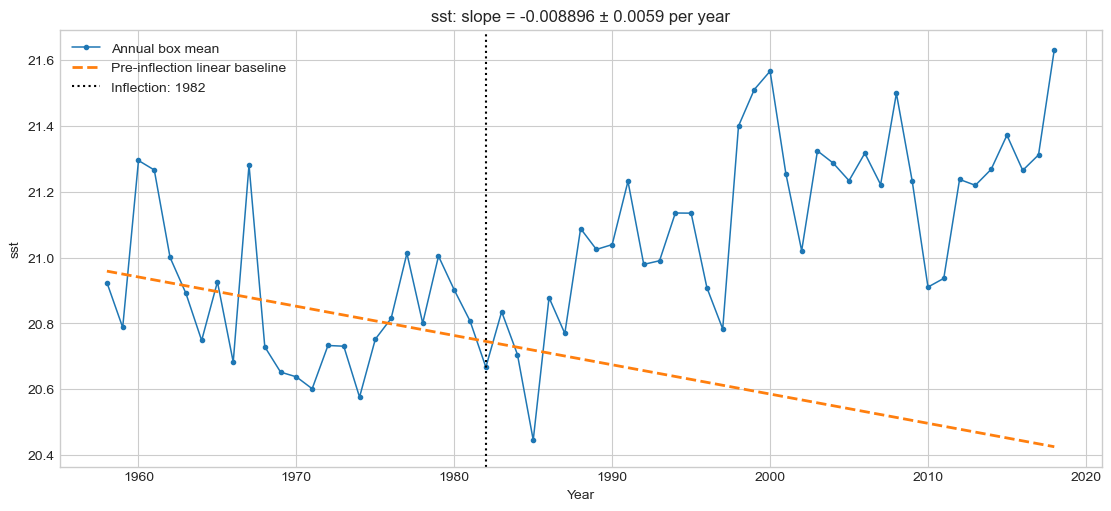

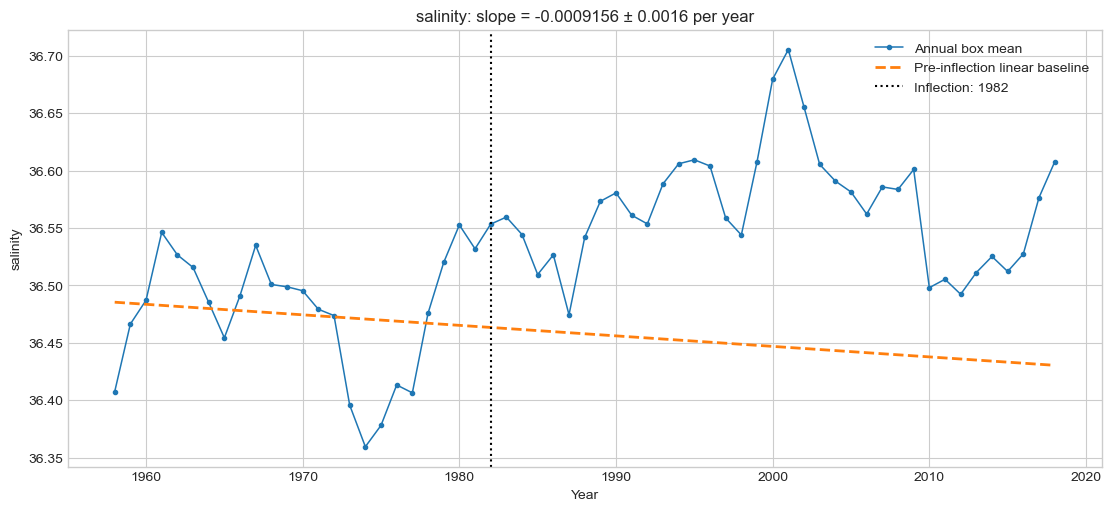

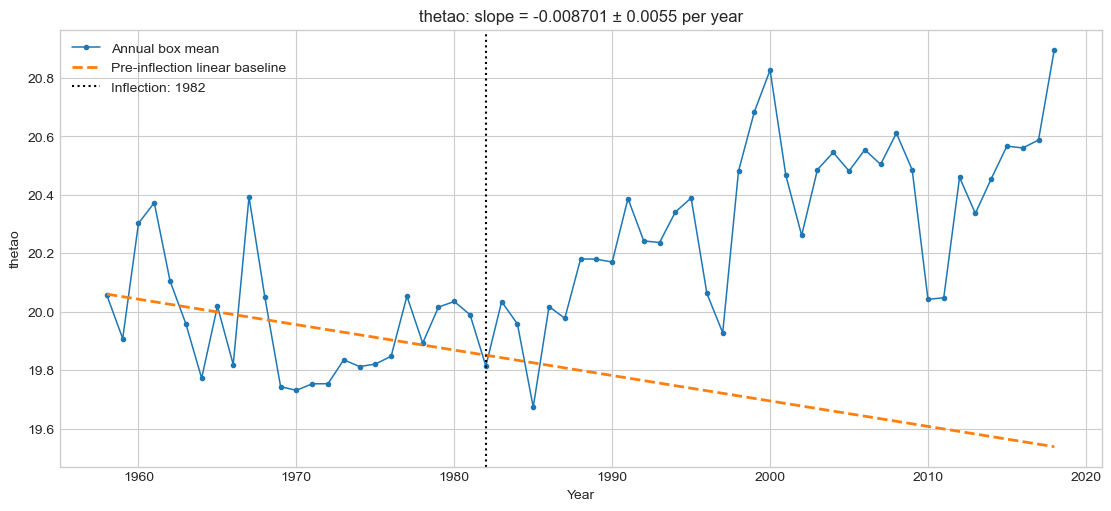

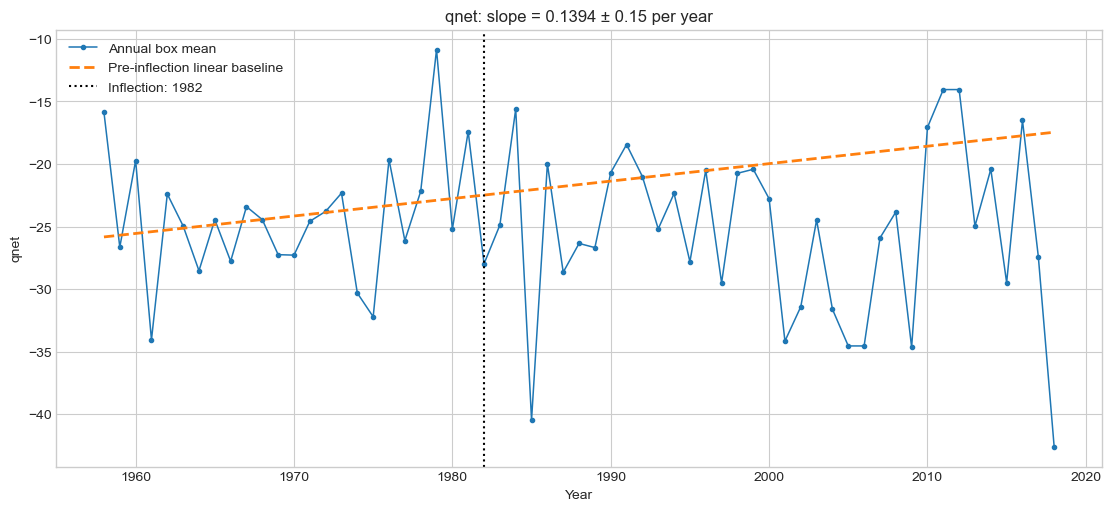

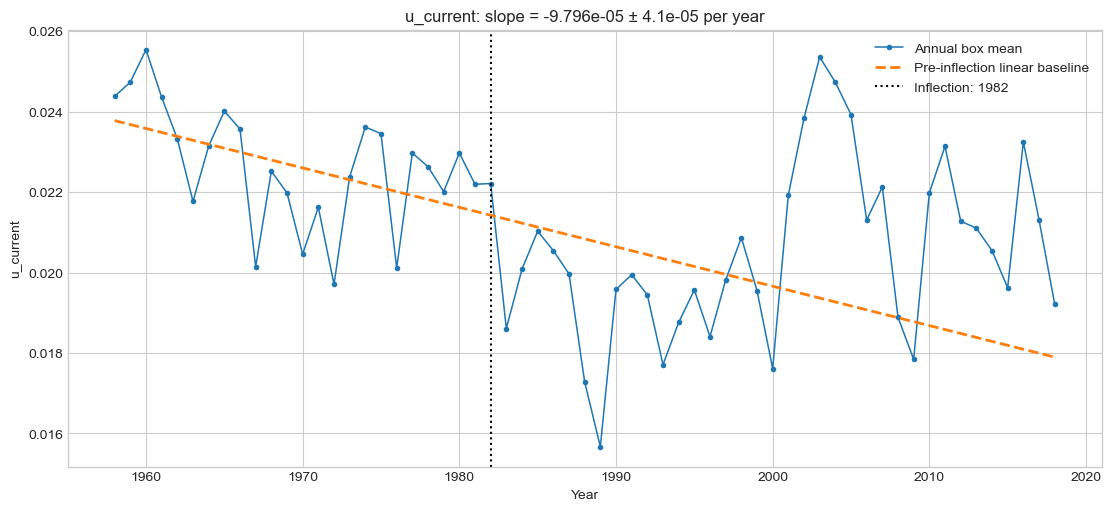

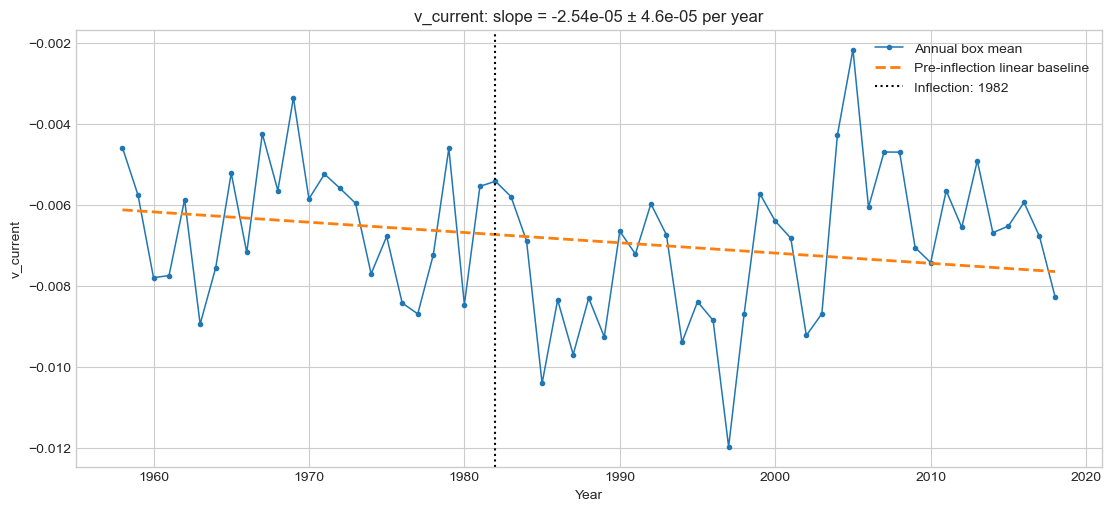

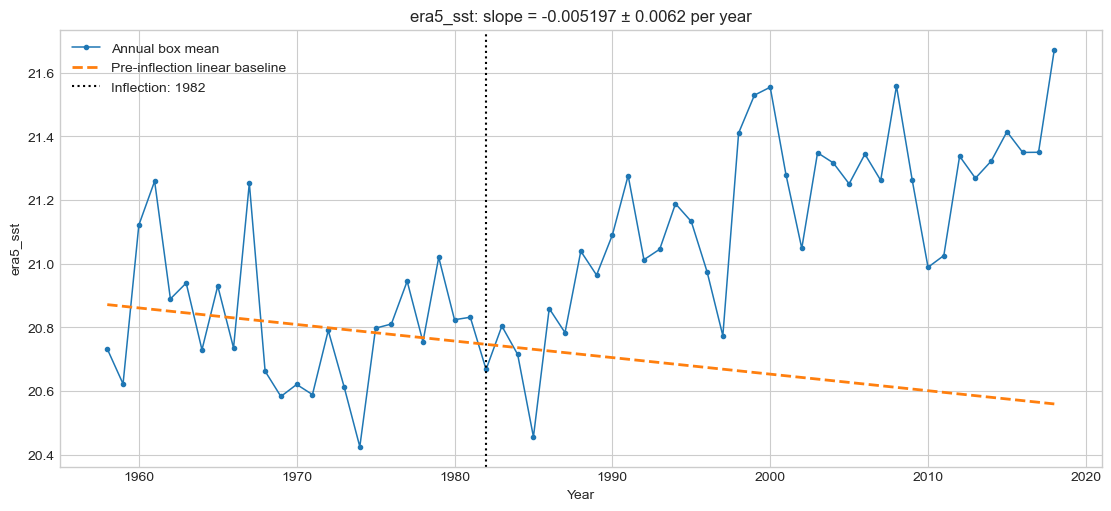

In [28]:
for feature in annual_df.columns:
    fit = fit_details[feature]

    expected_all = (
        fit["intercept_at_inflection"]
        + fit["slope_per_year"]
        * (years - INFLECTION_YEAR)
    )

    fig, ax = plt.subplots(
        figsize=(11, 5),
        constrained_layout=True,
    )

    ax.plot(
        years,
        annual_df[feature],
        "o-",
        ms=3,
        lw=1.1,
        label="Annual box mean",
    )

    ax.plot(
        years,
        expected_all,
        "--",
        lw=2,
        label="Pre-inflection linear baseline",
    )

    ax.axvline(
        INFLECTION_YEAR,
        color="black",
        ls=":",
        label=f"Inflection: {INFLECTION_YEAR}",
    )

    ax.set_xlabel("Year")
    ax.set_ylabel(feature)

    ax.set_title(
        f"{feature}: slope = "
        f"{fit['slope_per_year']:.4g} ± "
        f"{fit['slope_se']:.2g} per year"
    )

    ax.legend(loc="best")

    safe_name = "".join(
        ch if ch.isalnum() or ch in "-_"
        else "_"
        for ch in feature
    )

    fig.savefig(
        OUTPUT_DIR
        / f"{safe_name}_linear_baseline.png",
        dpi=180,
        bbox_inches="tight",
    )

    plt.show()